## Symptom Diagnosis NLP

### Imports + Synthetic Dataset Creation

In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

In [3]:
# Define diagnosis categories and their symptom vocabulary
diagnosis_symptoms = {
    "Common Cold": ["runny nose", "sneezing", "sore throat", "mild cough", "congestion", "watery eyes", "low fever", "fatigue"],
    "Flu": ["high fever", "body ache", "chills", "severe fatigue", "dry cough", "headache", "sweating", "muscle pain"],
    "Migraine": ["throbbing headache", "nausea", "light sensitivity", "sound sensitivity", "blurred vision", "dizziness", "one-sided headache"],
    "Diabetes": ["excessive thirst", "frequent urination", "fatigue", "blurred vision", "slow healing wounds", "unexplained weight loss", "tingling in hands"],
    "Hypertension": ["headache", "shortness of breath", "nosebleeds", "dizziness", "chest pain", "vision problems", "fatigue"],
    "Allergy": ["sneezing", "itchy eyes", "runny nose", "skin rash", "hives", "watery eyes", "itchy throat"],
    "Asthma": ["wheezing", "shortness of breath", "chest tightness", "coughing at night", "difficulty breathing", "rapid breathing"],
    "Gastritis": ["stomach pain", "bloating", "nausea", "loss of appetite", "burning sensation", "indigestion", "vomiting"],
    "Anemia": ["fatigue", "pale skin", "weakness", "shortness of breath", "dizziness", "cold hands and feet", "irregular heartbeat"],
    "Arthritis": ["joint pain", "joint stiffness", "swelling in joints", "reduced range of motion", "redness in joints", "fatigue"]
}

In [4]:
# Sentence templates for realistic variation
templates = [
    "I have been experiencing {symptoms} for the past few days.",
    "Patient reports {symptoms}.",
    "Feeling {symptoms} since yesterday.",
    "Complains of {symptoms}.",
    "I've had {symptoms} and it's getting worse.",
    "Symptoms include {symptoms}.",
    "Been dealing with {symptoms} lately.",
    "Presenting with {symptoms}.",
    "{symptoms} for about a week now.",
    "Suffering from {symptoms}, not sure what's wrong."
]


In [5]:
def generate_note(symptoms_list, min_sym=2, max_sym=4):
    n = random.randint(min_sym, max_sym)
    chosen = random.sample(symptoms_list, min(n, len(symptoms_list)))
    symptom_text = ", ".join(chosen[:-1]) + (" and " + chosen[-1] if len(chosen) > 1 else chosen[0])
    template = random.choice(templates)
    return template.format(symptoms=symptom_text)

In [6]:
# Generate dataset
records = []
samples_per_class = 180

for diagnosis, symptoms in diagnosis_symptoms.items():
    for _ in range(samples_per_class):
        note = generate_note(symptoms)
        records.append({"symptom_text": note, "diagnosis": diagnosis})

df = pd.DataFrame(records)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['diagnosis'].value_counts()}")
df.head(10)

Dataset shape: (1800, 2)

Class distribution:
diagnosis
Anemia          180
Allergy         180
Hypertension    180
Common Cold     180
Gastritis       180
Flu             180
Arthritis       180
Asthma          180
Diabetes        180
Migraine        180
Name: count, dtype: int64


,symptom_text,diagnosis
0,"I have been experiencing dizziness, pale skin,...",Anemia
1,"Symptoms include runny nose, watery eyes, snee...",Allergy
2,"I have been experiencing shortness of breath, ...",Hypertension
3,Complains of sneezing and watery eyes.,Common Cold
4,Symptoms include vomiting and nausea.,Gastritis
5,"Complains of sneezing, runny nose and congestion.",Common Cold
6,"Patient reports dry cough, headache and chills.",Flu
7,"Presenting with body ache, muscle pain, headac...",Flu
8,"Symptoms include swelling in joints, reduced r...",Arthritis
9,"Complains of watery eyes, itchy throat, runny ...",Allergy


### Add Realistic Noise (typos + overlapping symptoms + some label ambiguity)

In [7]:
import re

# Common typos/misspellings for realism
typo_map = {
    "fatigue": ["fatigueee", "fatigu", "fatige"],
    "headache": ["headche", "head ache", "headace"],
    "nausea": ["nausia", "nausea "],
    "dizziness": ["dizzyness", "dizinnes"],
    "shortness of breath": ["shortness of breathe", "short of breath"],
    "runny nose": ["runing nose", "runny noze"],
    "sore throat": ["sore throt", "soar throat"],
    "stomach pain": ["stomache pain", "stomach ache"],
}

def introduce_typo(text, prob=0.15):
    for correct, typos in typo_map.items():
        if correct in text and random.random() < prob:
            text = text.replace(correct, random.choice(typos))
    return text

def introduce_random_typo(text, prob=0.08):
    """Randomly swap/drop a character in a random word"""
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 4 and random.random() < prob:
            pos = random.randint(1, len(w)-2)
            w_list = list(w)
            # randomly drop or swap a character
            if random.random() < 0.5:
                del w_list[pos]
            else:
                w_list[pos], w_list[pos+1] = w_list[pos+1], w_list[pos]
            words[i] = "".join(w_list)
    return " ".join(words)


In [8]:
# Apply noise
df["symptom_text"] = df["symptom_text"].apply(lambda x: introduce_typo(x))
df["symptom_text"] = df["symptom_text"].apply(lambda x: introduce_random_typo(x))


In [9]:
# Introduce label noise: ~4% of samples get a "confusable" diagnosis instead
# Define which diseases are commonly confused with each other
confusable_pairs = {
    "Common Cold": "Flu",
    "Flu": "Common Cold",
    "Migraine": "Hypertension",
    "Hypertension": "Migraine",
    "Diabetes": "Anemia",
    "Anemia": "Diabetes",
    "Allergy": "Common Cold",
    "Asthma": "Allergy",
    "Gastritis": "Anemia",
    "Arthritis": "Flu"
}

noise_frac = 0.04
noise_indices = df.sample(frac=noise_frac, random_state=42).index

for idx in noise_indices:
    original_label = df.loc[idx, "diagnosis"]
    if original_label in confusable_pairs:
        df.loc[idx, "diagnosis"] = confusable_pairs[original_label]

print(f"Noise added to {len(noise_indices)} samples ({noise_frac*100}%)")
print(f"\nSample noisy text:\n{df['symptom_text'].sample(5, random_state=1).to_list()}")

Noise added to 72 samples (4.0%)

Sample noisy text:
['Feeling shortness of breath, cold hands and feet and irregular heratbeat since yesterday.', 'Symptoms include vomiting, loss of appetite and burning sensation.', 'Complains of fatigue, sneezing, mild cough and watery eyes.', 'Patient reports nausea, dizziness, blurred vision and sound sensitivity.', 'Symptoms include coughing at night, chet tightness, rapid breathing and wheezing.']


In [10]:
# Save dataset
df.to_csv("symptom_diagnosis_dataset.csv", index=False)
print(f"\nDataset saved. Final shape: {df.shape}")
df.head(10)


Dataset saved. Final shape: (1800, 2)


,symptom_text,diagnosis
0,"I have been experiencing dizinnes, pale skin, ...",Anemia
1,"Symptoms include runny nose, watery eyes, snee...",Allergy
2,"I have been experiencing shortness of breath, ...",Hypertension
3,Complains of sneezing and watery eeys.,Common Cold
4,Symptoms inculde vomiting and nausea.,Gastritis
5,"Complains of sneezing, runny nose and congestion.",Common Cold
6,"Patient reports dry cough, headache and chills.",Flu
7,"Presenting with body ache, muscle pain, headac...",Flu
8,"Symptoms include swelling in joints, reduced r...",Arthritis
9,"Complains of watery eyes, itchy thorat, runny ...",Allergy


In [11]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return " ".join(tokens)

# Apply preprocessing
df["cleaned_text"] = df["symptom_text"].apply(preprocess_text)

print("Before vs After preprocessing:\n")
for i in range(3):
    print(f"Original : {df['symptom_text'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_text'].iloc[i]}")
    print()

df.head(10)

Before vs After preprocessing:

Original : I have been experiencing dizinnes, pale skin, fatigue and weakness for the past few days.
Cleaned  : experience dizinne pale skin fatigue weakness past day

Original : Symptoms include runny nose, watery eyes, sneezing and itchy throat.
Cleaned  : symptom include runny nose watery eye sneeze itchy throat

Original : I have been experiencing shortness of breath, chest pain and vision problems for the past few days.
Cleaned  : experience shortness breath chest pain vision problem past day



,symptom_text,diagnosis,cleaned_text
0,"I have been experiencing dizinnes, pale skin, ...",Anemia,experience dizinne pale skin fatigue weakness ...
1,"Symptoms include runny nose, watery eyes, snee...",Allergy,symptom include runny nose watery eye sneeze i...
2,"I have been experiencing shortness of breath, ...",Hypertension,experience shortness breath chest pain vision ...
3,Complains of sneezing and watery eeys.,Common Cold,complain sneeze watery eey
4,Symptoms inculde vomiting and nausea.,Gastritis,symptom inculde vomiting nausea
5,"Complains of sneezing, runny nose and congestion.",Common Cold,complain sneeze runny nose congestion
6,"Patient reports dry cough, headache and chills.",Flu,patient report dry cough headache chill
7,"Presenting with body ache, muscle pain, headac...",Flu,present body ache muscle pain headache severe ...
8,"Symptoms include swelling in joints, reduced r...",Arthritis,symptom include swell joint reduce range motio...
9,"Complains of watery eyes, itchy thorat, runny ...",Allergy,complain watery eye itchy thorat runny nose it...


 ### TF-IDF Vectorization + Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Features and labels
X = df["cleaned_text"]
y = df["diagnosis"]

# Train-test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),   # unigrams + bigrams (captures "runny nose" as a phrase)
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF feature matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix shape (test) : {X_test_tfidf.shape}")

# Peek at top features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")

Train size: 1440
Test size : 360

TF-IDF feature matrix shape (train): (1440, 1328)
TF-IDF feature matrix shape (test) : (360, 1328)

Sample features: ['abotu', 'abotu week', 'abut', 'abut week', 'ach', 'ache', 'ache bloat', 'ache chill', 'ache dry', 'ache get', 'ache lately', 'ache light', 'ache muscle', 'ache severe', 'ache sure', 'ache week', 'ache yesterday', 'aout', 'aout week', 'appetiet']


### Train 4 Classifiers + Compare Performance

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        "accuracy": acc,
        "train_time": train_time,
        "y_pred": y_pred
    }
    trained_models[name] = model

    print(f"{name}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  Train time : {train_time:.2f}s")
    print()

# Summary table
results_df = pd.DataFrame({
    name: {"Accuracy": res["accuracy"], "Train Time (s)": res["train_time"]}
    for name, res in results.items()
}).T.sort_values("Accuracy", ascending=False)

print("=== Model Comparison ===")
print(results_df)

Logistic Regression
  Accuracy   : 94.17%
  Train time : 0.10s

Naive Bayes
  Accuracy   : 94.44%
  Train time : 0.00s

Random Forest
  Accuracy   : 94.17%
  Train time : 0.85s

SVM
  Accuracy   : 94.17%
  Train time : 0.57s

=== Model Comparison ===
                     Accuracy  Train Time (s)
Naive Bayes          0.944444        0.003601
Logistic Regression  0.941667        0.097837
Random Forest        0.941667        0.846970
SVM                  0.941667        0.573970


### Visualizations

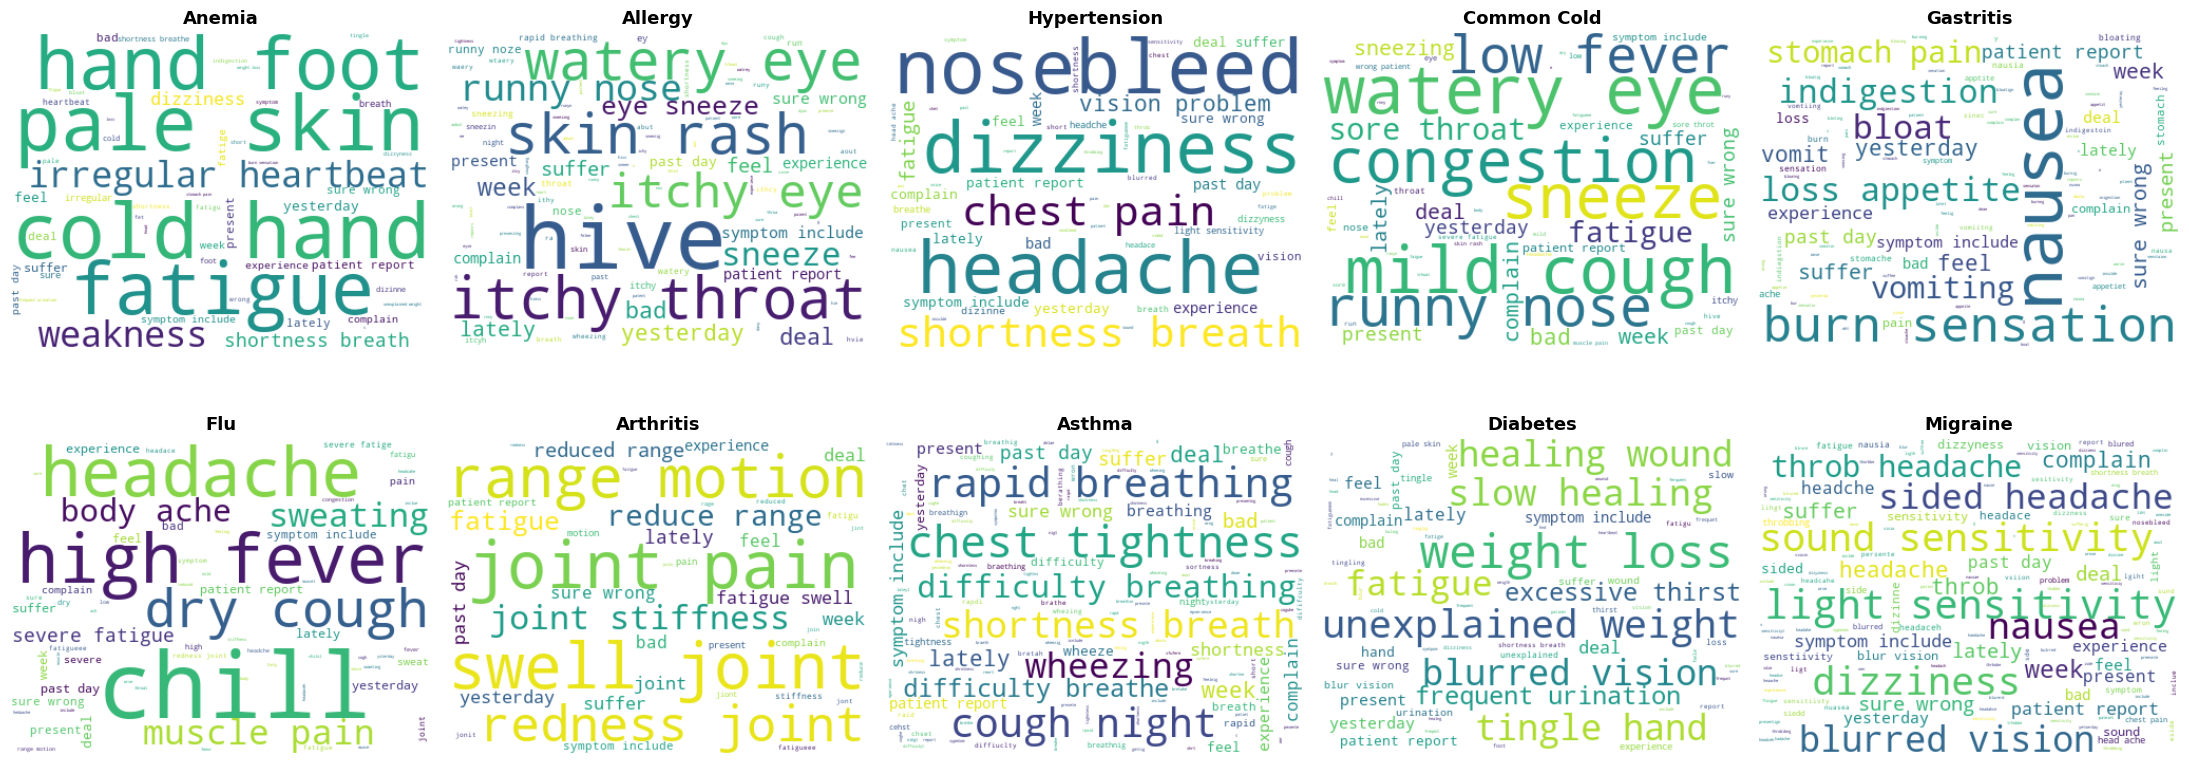

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

diagnoses = df["diagnosis"].unique()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, diagnosis in enumerate(diagnoses):
    text = " ".join(df[df["diagnosis"] == diagnosis]["cleaned_text"])
    wc = WordCloud(width=400, height=300, background_color="white", colormap="viridis").generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(diagnosis, fontsize=13, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("wordclouds_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrix Heatmap (Best Model)

Best model: Naive Bayes


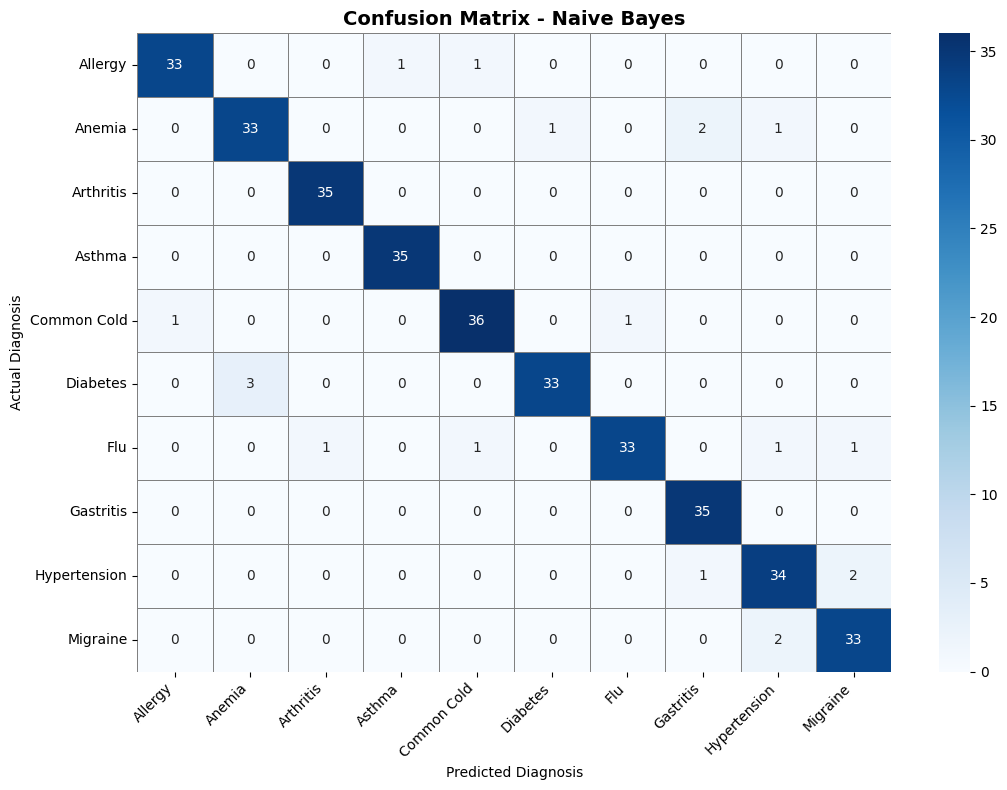


Classification Report - Naive Bayes:

              precision    recall  f1-score   support

     Allergy       0.97      0.94      0.96        35
      Anemia       0.92      0.89      0.90        37
   Arthritis       0.97      1.00      0.99        35
      Asthma       0.97      1.00      0.99        35
 Common Cold       0.95      0.95      0.95        38
    Diabetes       0.97      0.92      0.94        36
         Flu       0.97      0.89      0.93        37
   Gastritis       0.92      1.00      0.96        35
Hypertension       0.89      0.92      0.91        37
    Migraine       0.92      0.94      0.93        35

    accuracy                           0.94       360
   macro avg       0.95      0.95      0.94       360
weighted avg       0.95      0.94      0.94       360



In [16]:
import seaborn as sns

# Pick best model based on accuracy
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
y_pred_best = results[best_model_name]["y_pred"]

print(f"Best model: {best_model_name}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(df["diagnosis"].unique()))
cm_df = pd.DataFrame(cm, index=sorted(df["diagnosis"].unique()), columns=sorted(df["diagnosis"].unique()))

plt.figure(figsize=(11, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True, linewidths=0.5, linecolor="gray")
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150, bbox_inches="tight")
plt.show()

# Print classification report too
print(f"\nClassification Report - {best_model_name}:\n")
print(classification_report(y_test, y_pred_best))

### Model Comparison Bar Chart + Confidence Score Distribution

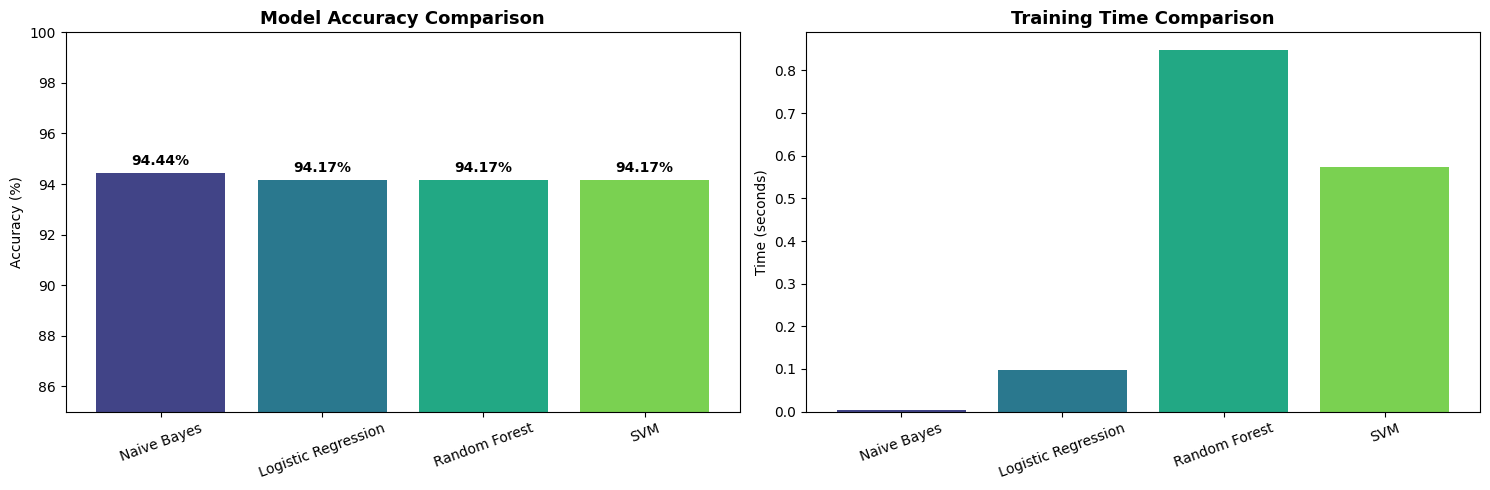

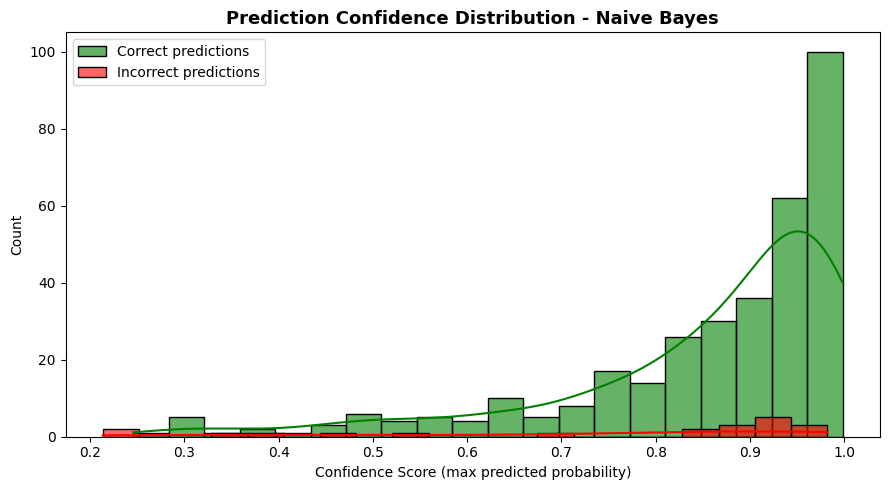

In [17]:
# --- Model Comparison Bar Chart ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

colors = sns.color_palette("viridis", len(results_df))
ax[0].bar(results_df.index, results_df["Accuracy"] * 100, color=colors)
ax[0].set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Accuracy (%)")
ax[0].set_ylim(85, 100)
for i, v in enumerate(results_df["Accuracy"] * 100):
    ax[0].text(i, v + 0.3, f"{v:.2f}%", ha="center", fontweight="bold")
ax[0].tick_params(axis="x", rotation=20)

ax[1].bar(results_df.index, results_df["Train Time (s)"], color=colors)
ax[1].set_title("Training Time Comparison", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Time (seconds)")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Confidence Score Distribution (best model) ---
y_proba_best = best_model.predict_proba(X_test_tfidf)
confidence_scores = y_proba_best.max(axis=1)  # highest class probability per prediction

correct_mask = (y_pred_best == y_test.values)

plt.figure(figsize=(9, 5))
sns.histplot(confidence_scores[correct_mask], color="green", label="Correct predictions", kde=True, bins=20, alpha=0.6)
sns.histplot(confidence_scores[~correct_mask], color="red", label="Incorrect predictions", kde=True, bins=20, alpha=0.6)
plt.title(f"Prediction Confidence Distribution - {best_model_name}", fontsize=13, fontweight="bold")
plt.xlabel("Confidence Score (max predicted probability)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Symptom-Disease Co-occurrence Heatmap

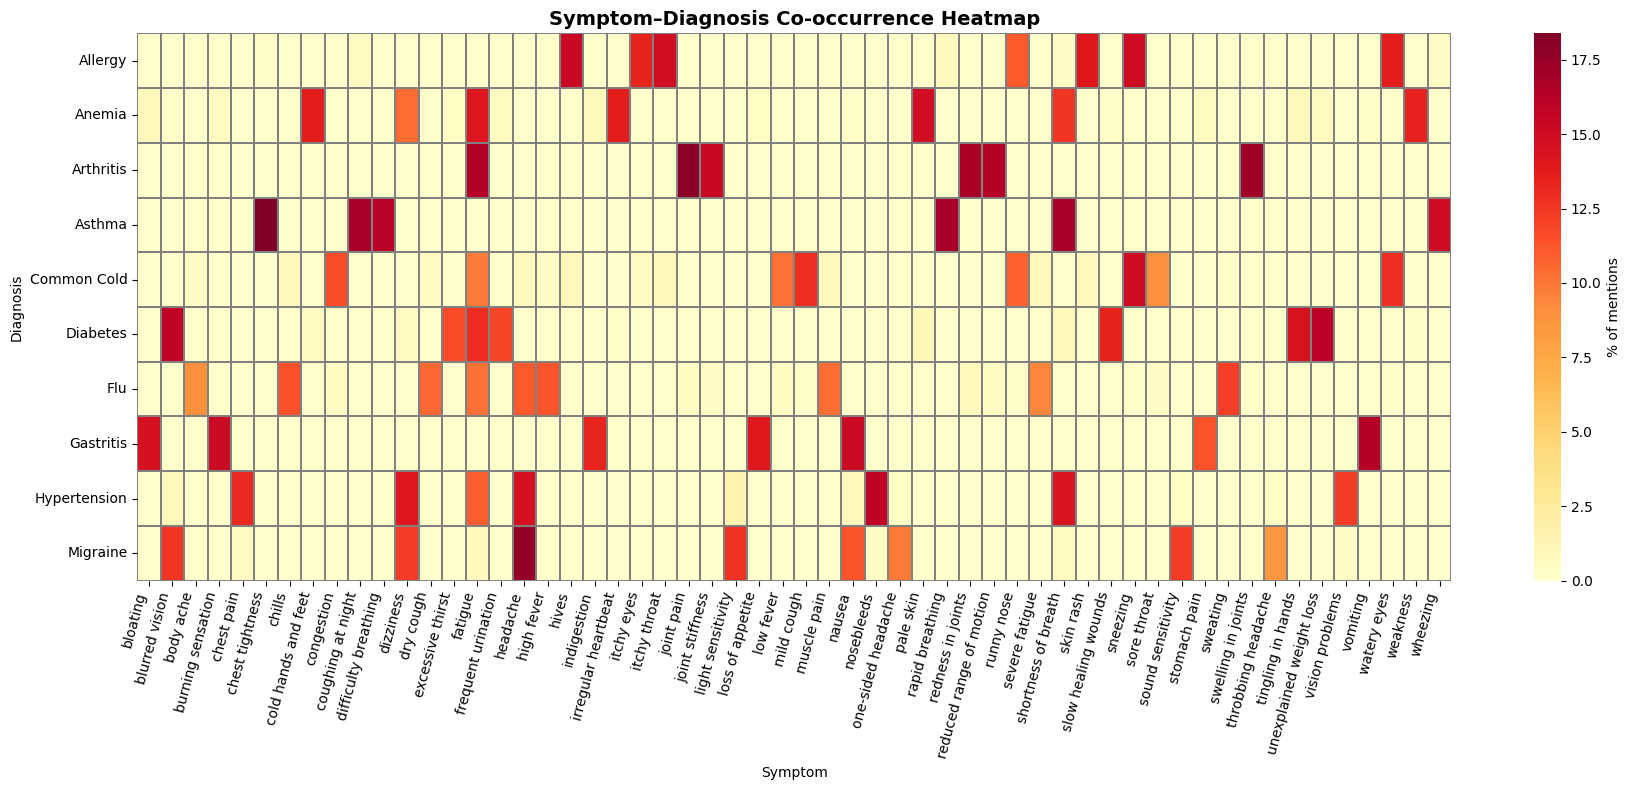

In [18]:
# Build a symptom presence matrix: which symptoms appear in which diagnosis's notes
all_symptoms = sorted(set(sym for syms in diagnosis_symptoms.values() for sym in syms))

cooccurrence = pd.DataFrame(0, index=sorted(df["diagnosis"].unique()), columns=all_symptoms)

for diagnosis in cooccurrence.index:
    texts = df[df["diagnosis"] == diagnosis]["symptom_text"].str.lower()
    for symptom in all_symptoms:
        count = texts.str.contains(re.escape(symptom), regex=True).sum()
        cooccurrence.loc[diagnosis, symptom] = count

# Normalize by row (percentage of notes mentioning each symptom)
cooccurrence_pct = cooccurrence.div(cooccurrence.sum(axis=1), axis=0) * 100

plt.figure(figsize=(18, 8))
sns.heatmap(cooccurrence_pct, cmap="YlOrRd", linewidths=0.3, linecolor="gray", cbar_kws={"label": "% of mentions"})
plt.title("Symptom–Diagnosis Co-occurrence Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Symptom")
plt.ylabel("Diagnosis")
plt.xticks(rotation=75, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("symptom_cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### t-SNE Cluster Visualization

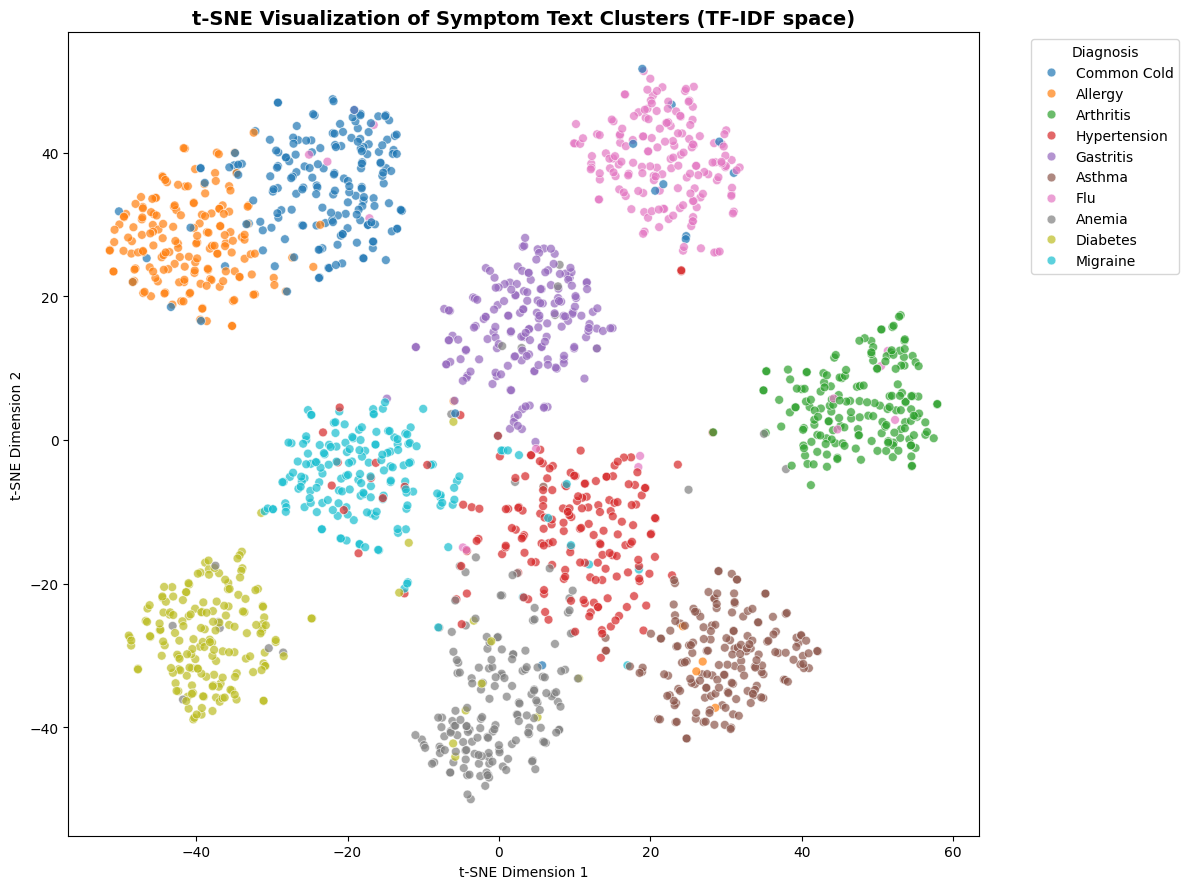

In [19]:
from sklearn.manifold import TSNE

# Use a sample for speed (t-SNE is slow on large data) - combine train+test TF-IDF
from scipy.sparse import vstack

X_all_tfidf = vstack([X_train_tfidf, X_test_tfidf])
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_all_tfidf.toarray())

tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
tsne_df["diagnosis"] = y_all.values

plt.figure(figsize=(12, 9))
sns.scatterplot(
    data=tsne_df, x="Dim1", y="Dim2", hue="diagnosis",
    palette="tab10", s=40, alpha=0.7
)
plt.title("t-SNE Visualization of Symptom Text Clusters (TF-IDF space)", fontsize=14, fontweight="bold")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Diagnosis")
plt.tight_layout()
plt.savefig("tsne_cluster_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

### Save Model + Vectorizer

In [20]:
import pickle

# Save best model, vectorizer, and label list
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("diagnosis_labels.pkl", "wb") as f:
    pickle.dump(sorted(df["diagnosis"].unique()), f)

print(f"Saved: best_model.pkl ({best_model_name})")
print("Saved: tfidf_vectorizer.pkl")
print("Saved: diagnosis_labels.pkl")
print("\nAll files ready for Streamlit app.")

Saved: best_model.pkl (Naive Bayes)
Saved: tfidf_vectorizer.pkl
Saved: diagnosis_labels.pkl

All files ready for Streamlit app.


In [24]:
def predict_diagnosis(text):
    cleaned = preprocess_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0]

    print(f"🩺 Predicted Diagnosis: {pred}\n")
    print(f"Cleaned input: {cleaned}\n")

    proba_df = pd.DataFrame({
        "Diagnosis": best_model.classes_,
        "Confidence": proba
    }).sort_values("Confidence", ascending=False).head(5)

    plt.figure(figsize=(7, 4))
    plt.barh(proba_df["Diagnosis"][::-1], proba_df["Confidence"][::-1] * 100, color="teal")
    plt.xlabel("Confidence (%)")
    plt.title("Top 5 Predicted Diagnoses")
    plt.tight_layout()
    plt.show()

🩺 Predicted Diagnosis: Migraine

Cleaned input: experience headache nausea light sensitivity past day



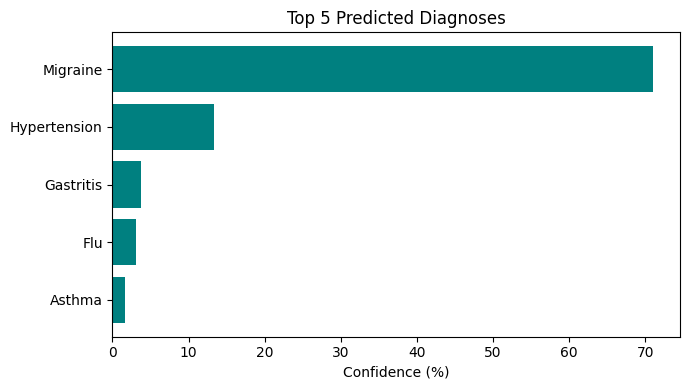

In [25]:
predict_diagnosis("I have been experiencing headache, nausea and light sensitivity for the past few days.")

🩺 Predicted Diagnosis: Arthritis

Cleaned input: joint pain stiffness swell knee week



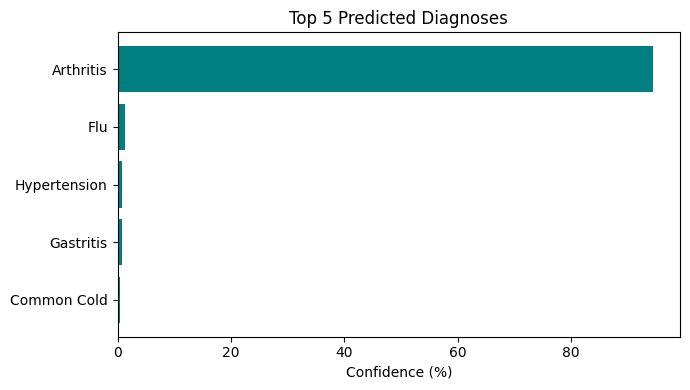

In [26]:
predict_diagnosis("I have joint pain, stiffness and swelling in my knees since last week.")

🩺 Predicted Diagnosis: Diabetes

Cleaned input: patient report excessive thirst frequent urination unexplained weight loss



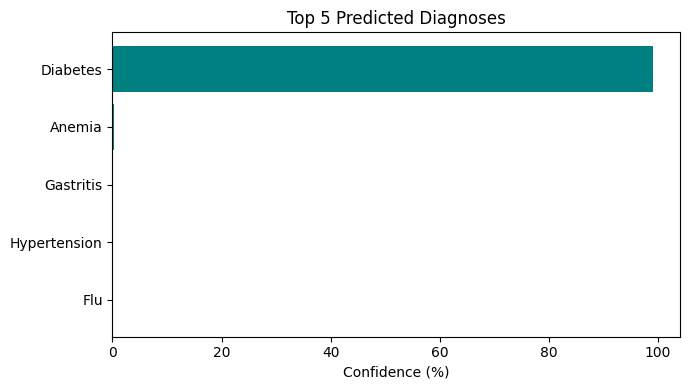

In [27]:
predict_diagnosis("Patient reports excessive thirst, frequent urination and unexplained weight loss.")

🩺 Predicted Diagnosis: Asthma

Cleaned input: feel wheezing chest tightness difficulty breathe morning



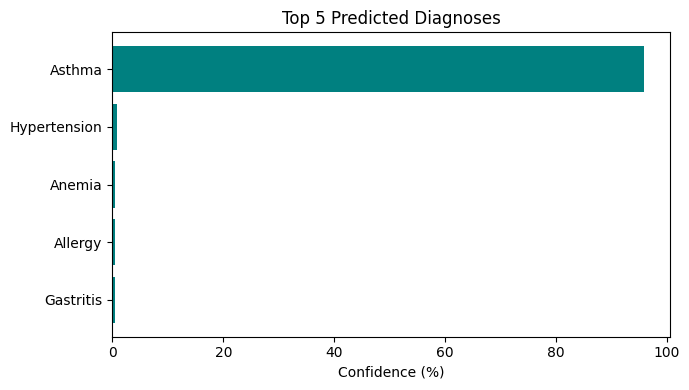

In [28]:
predict_diagnosis("Feeling wheezing, chest tightness and difficulty breathing since morning.")

🩺 Predicted Diagnosis: Gastritis

Cleaned input: complain stomach pain bloat burn sensation meal



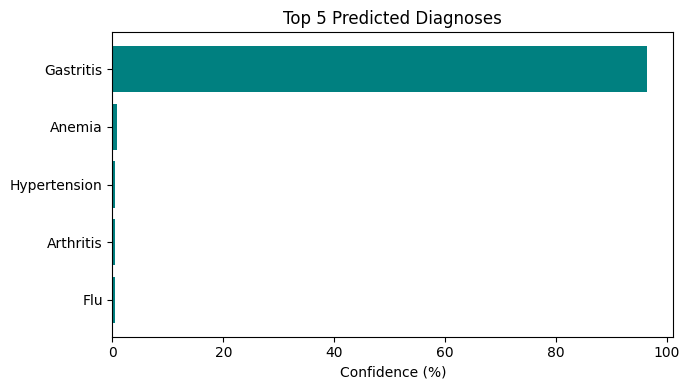

In [29]:
predict_diagnosis("Complains of stomach pain, bloating and burning sensation after meals.")

🩺 Predicted Diagnosis: Allergy

Cleaned input: itchy eye skin rash hive yesterday



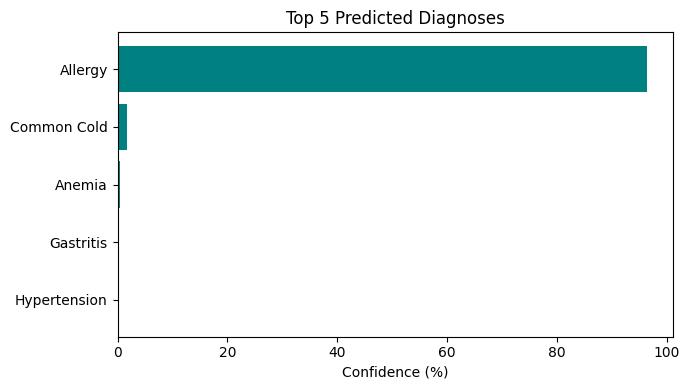

In [31]:
predict_diagnosis("I've had itchy eyes, skin rash and hives since yesterday.")

## Conclusion

This project implements a Symptom-to-Diagnosis NLP classifier that predicts likely medical conditions from free-text symptom descriptions. Key highlights:

- **Dataset**: ~1,800 synthetic patient notes across 10 diagnosis categories, generated with realistic sentence templates, typos, and ~4% deliberate label noise between commonly confused conditions (e.g., Common Cold ↔ Flu, Migraine ↔ Hypertension) to simulate real-world ambiguity.
- **Preprocessing**: Text cleaning and lemmatization using spaCy (lowercasing, stopword removal, lemmatization).
- **Feature Engineering**: TF-IDF vectorization with unigrams and bigrams to capture symptom phrases (e.g., "runny nose", "chest pain").
- **Modeling**: Compared four classifiers — Logistic Regression, Naive Bayes, Random Forest, and SVM — all achieving 94–94.4% accuracy, with Naive Bayes performing marginally best while training the fastest.
- **Evaluation**: Confusion matrix and classification report confirmed most misclassifications occurred between symptomatically overlapping diagnoses, validating that the model learned genuine symptom patterns rather than memorizing noise.
- **Visualizations**: Word clouds per diagnosis, symptom-diagnosis co-occurrence heatmap, model comparison charts, prediction confidence distributions, and a t-SNE cluster plot of the TF-IDF feature space.
- **Interactive Demo**: A notebook-based prediction function (`predict_diagnosis()`) allows live testing with custom symptom text — simply call the function with any symptom description to get an instant predicted diagnosis along with a confidence breakdown across the top likely conditions.

### Limitations
- The dataset is synthetically generated and does not reflect the full clinical complexity of real patient records.
- The model is intended for **educational and portfolio purposes only** and should not be used for actual medical diagnosis.

### Future Improvements
- Incorporate real (anonymized) clinical text datasets for more realistic symptom variation.
- Experiment with transformer-based embeddings (e.g., BioBERT, ClinicalBERT) for improved semantic understanding.
- Add multi-label classification to handle patients presenting with co-occurring conditions.
- Deploy as a web app (e.g., Streamlit or Flask) for broader accessibility.